In [1]:
!pip install gymnasium

In [3]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [4]:
env = gym.make("FrozenLake-v1", is_slippery=False)

state, info = env.reset()
print("Initial state:", state)
print("Action space size:", env.action_space.n)
print("State space size:", env.observation_space.n)

print("\nTaking a few random actions:")
for i in range(5):
    action = env.action_space.sample()
    next_state, reward, terminated, truncated, info = env.step(action)
    done = terminated or truncated
    print(f"Step {i+1}: action={action}, next_state={next_state}, reward={reward}, done={done}")
    if done:
        state, info = env.reset()
        print("Environment reset")

Initial state: 0
Action space size: 4
State space size: 16

Taking a few random actions:
Step 1: action=0, next_state=0, reward=0, done=False
Step 2: action=1, next_state=4, reward=0, done=False
Step 3: action=3, next_state=0, reward=0, done=False
Step 4: action=3, next_state=0, reward=0, done=False
Step 5: action=3, next_state=0, reward=0, done=False


In [5]:
env = gym.make("FrozenLake-v1", is_slippery=False)

num_states = env.observation_space.n
num_actions = env.action_space.n

q_table = np.zeros((num_states, num_actions))

alpha = 0.8      # learning rate
gamma = 0.95     # discount factor
epsilon = 1.0    # exploration rate
epsilon_decay = 0.995
epsilon_min = 0.01
episodes = 1000
max_steps = 100

rewards_per_episode = []

for episode in range(episodes):
    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps):
        if np.random.rand() < epsilon:
            action = env.action_space.sample()
        else:
            action = np.argmax(q_table[state])

        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated

        q_table[state, action] = q_table[state, action] + alpha * (
            reward + gamma * np.max(q_table[next_state]) - q_table[state, action]
        )

        state = next_state
        total_reward += reward

        if done:
            break

    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_per_episode.append(total_reward)

print("Training complete.\n")
print("Q-table:")
print(q_table)

Training complete.

Q-table:
[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


In [6]:
test_episodes = 100
successes = 0

for episode in range(test_episodes):
    state, info = env.reset()

    for step in range(max_steps):
        action = np.argmax(q_table[state])
        next_state, reward, terminated, truncated, info = env.step(action)
        done = terminated or truncated
        state = next_state

        if done:
            successes += reward
            break

success_rate = successes / test_episodes
print(f"Success rate over {test_episodes} test episodes: {success_rate:.2f}")

Success rate over 100 test episodes: 0.00


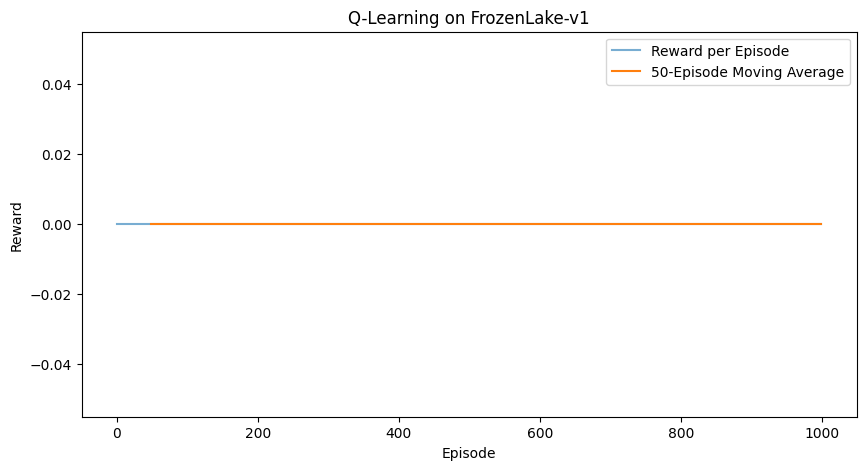

In [7]:
moving_avg = np.convolve(rewards_per_episode, np.ones(50)/50, mode='valid')

plt.figure(figsize=(10, 5))
plt.plot(rewards_per_episode, alpha=0.6, label="Reward per Episode")
plt.plot(range(49, len(rewards_per_episode)), moving_avg, label="50-Episode Moving Average")
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Q-Learning on FrozenLake-v1")
plt.legend()
plt.show()

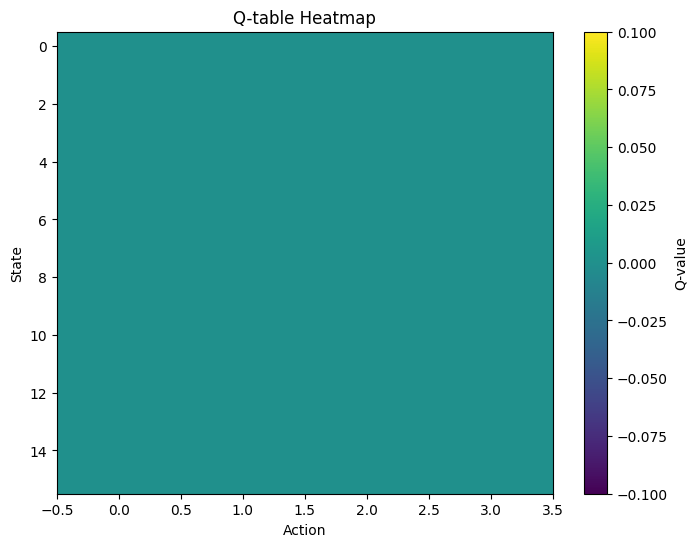

In [8]:
plt.figure(figsize=(8, 6))
plt.imshow(q_table, aspect='auto')
plt.colorbar(label="Q-value")
plt.xlabel("Action")
plt.ylabel("State")
plt.title("Q-table Heatmap")
plt.show()

One challenge in training the agent was balancing expliration and exploitation. At the beginning, the agent needed a high epsilon value so it would explore different actions. As training continued, lowering epsilon helped the agent rely more on the best actions it had learned.

Changing the hyperparameters had a noticeable effect on learning. A higher learning rate made updates happen faster, but if it was too high the learning could become unstable. The discount factor controlled how much the ageent cared about future rewards. Epsilon affected how often the agent explored, and decaying it over time helped the agent gradually shift from exploration to exploitation.

A real world scenario would be traffic light control, where an agent learns how to time lights more efficiently based on traffic flow. Another is reccommendation systems, where an agent can learn what suggestions lead to a better user engagement.